In [ ]:
!pip install librosa soundfile numpy scipy matplotlib

In [ ]:
# Imports
import numpy as np
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

In [ ]:
import matplotlib.pyplot as plt
import librosa.display
import numpy as np

def plot_waveforms(original, denoised, sr, channel_names=None):
    """
    original, denoised: shape (channels, samples)
    """
    channels = original.shape[0]
    t_orig = np.linspace(0, original.shape[1]/sr, original.shape[1])
    t_deno = np.linspace(0, denoised.shape[1]/sr, denoised.shape[1])

    plt.figure(figsize=(15, 4*channels))

    for ch in range(channels):
        plt.subplot(channels, 1, ch+1)
        plt.plot(t_orig, original[ch], label="Original", alpha=0.7)
        plt.plot(t_deno, denoised[ch], label="Denoised", alpha=0.7)
        plt.title(f"Waveform (Channel {ch+1})")
        plt.xlabel("Time (s)")
        plt.ylabel("Amplitude")
        plt.legend()

    plt.tight_layout()
    plt.show()


def plot_spectrogram(y, sr, title="Spectrogram"):
    """
    y: 1D signal
    """
    S = librosa.stft(y, n_fft=1024, hop_length=256)
    S_db = librosa.amplitude_to_db(np.abs(S), ref=np.max)

    plt.figure(figsize=(14, 4))
    librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='log')
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def load_audio_stereo(path, sr=16000):
    y, sr = librosa.load(path, sr=sr, mono=False)
    if y.ndim == 1:
        y = y[np.newaxis, :]  
    return y, sr

def save_audio_stereo(path, y, sr):
    sf.write(path, y.T, sr)


In [ ]:
def load_audio(path, sr=16000, mono=True):
    y, sr = librosa.load(path, sr=sr, mono=mono)
   
    y = y.astype(np.float32)
    return y, sr

def save_audio(path, y, sr):
    sf.write(path, y, sr)

def stft(y, n_fft=2048, hop_length=None, win_length=None):
    if hop_length is None:
        hop_length = n_fft // 4
    if win_length is None:
        win_length = n_fft
    S = librosa.stft(y, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window='hann')
    return S, hop_length, win_length

def istft(S, hop_length, win_length, n_fft=None):
    return librosa.istft(S, hop_length=hop_length, win_length=win_length, window='hann')

def estimate_noise_spectrum(y, sr, n_fft=2048, noise_frames=6):
    S, hop, win = stft(y, n_fft=n_fft)
    mag = np.abs(S)
    frame_energy = mag.mean(axis=0)  
    idx = np.argsort(frame_energy)[:noise_frames]  
    noise_spectrum = mag[:, idx].mean(axis=1)  
    return noise_spectrum, S, hop, win


def spectral_subtract_denoise(y, sr, n_fft=2048, alpha=1.0, beta=0.001, noise_frames=6, freq_smooth=3, time_smooth_alpha=0.8):
    noise_spec, S, hop, win = estimate_noise_spectrum(y, sr, n_fft=n_fft, noise_frames=noise_frames)
    mag = np.abs(S)
    phase = np.angle(S)

    
    noise_mat = noise_spec[:, np.newaxis]

    
    sub = mag - alpha * noise_mat
    floor = beta * noise_mat
    mag_hat = np.maximum(sub, floor)

   
    mag_hat = median_filter(mag_hat, size=(freq_smooth, 1))

   
    T = mag_hat.shape[1]
    for t in range(1, T):
        mag_hat[:, t] = time_smooth_alpha * mag_hat[:, t-1] + (1 - time_smooth_alpha) * mag_hat[:, t]

   
    S_hat = mag_hat * np.exp(1j * phase)
    y_hat = istft(S_hat, hop, win)
    return y_hat


def wiener_denoise(y, sr, n_fft=2048, noise_frames=6, eps=1e-10, freq_smooth=3, time_smooth_alpha=0.85):
    noise_spec, S, hop, win = estimate_noise_spectrum(y, sr, n_fft=n_fft, noise_frames=noise_frames)
    mag = np.abs(S)
    mag2 = mag**2
    noise_psd = (noise_spec**2)[:, np.newaxis]  


    snr_est = np.maximum((mag2 - noise_psd) / (noise_psd + eps), 0.0)


    G = snr_est / (1.0 + snr_est)
   
    G = median_filter(G, size=(freq_smooth,1))
   
    T = G.shape[1]
    for t in range(1, T):
        G[:, t] = time_smooth_alpha * G[:, t-1] + (1 - time_smooth_alpha) * G[:, t]

    S_hat = G * S
    y_hat = istft(S_hat, hop, win)
    return y_hat


Loaded audio:
 - Sample rate: 16000
 - Channels: 1
 - Length: 397824 samples
Denoising channel 1...


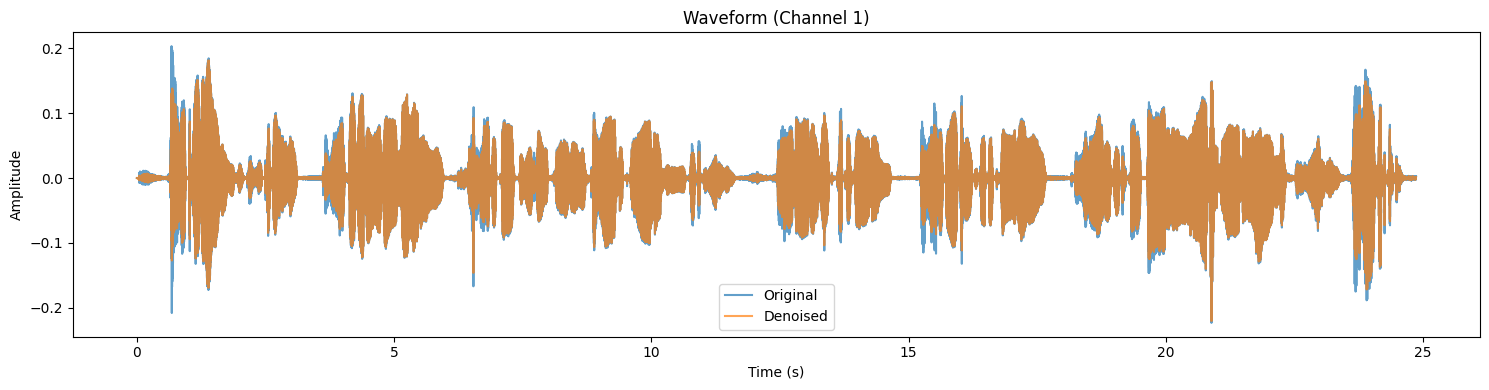

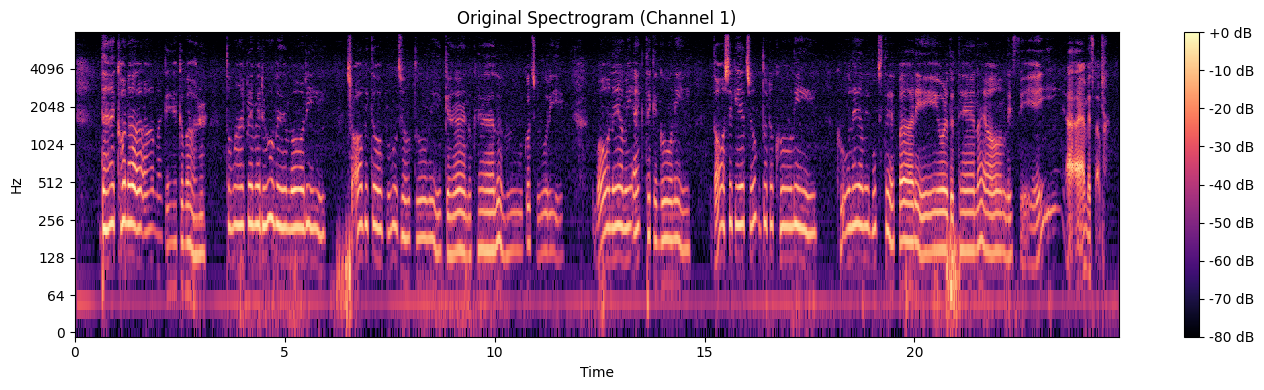

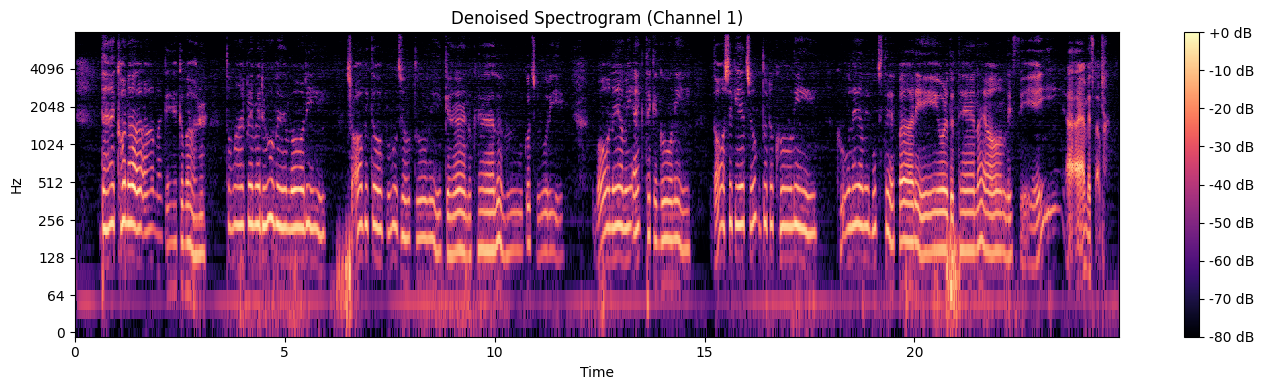

Saved: denoised_stereo.wav


In [ ]:


input_path = "1010.mp3"   # change to your file name
y_stereo, sr = load_audio_stereo(input_path)

print("Loaded audio:")
print(" - Sample rate:", sr)
print(" - Channels:", y_stereo.shape[0])
print(" - Length:", y_stereo.shape[1], "samples")

denoised_channels = []


for ch in range(y_stereo.shape[0]):
    print(f"Denoising channel {ch+1}...")
    y_hat = wiener_denoise(y_stereo[ch], sr, n_fft=2048, noise_frames=8)
    denoised_channels.append(y_hat)

min_len = min(len(c) for c in denoised_channels)
y_denoised = np.array([c[:min_len] for c in denoised_channels])
y_original_aligned = np.array([c[:min_len] for c in y_stereo])

plot_waveforms(y_original_aligned, y_denoised, sr)


plot_spectrogram(y_original_aligned[0], sr, title="Original Spectrogram (Channel 1)")
plot_spectrogram(y_denoised[0], sr, title="Denoised Spectrogram (Channel 1)")

output_path = "denoised_stereo.wav"
save_audio_stereo(output_path, y_denoised, sr)

print("Saved:", output_path)
